In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#downloaded data set from kaggle
ds=pd.read_csv("Salary_Data.csv")
X=ds["YearsExperience"].values #feature data
Y=ds["Salary"].values


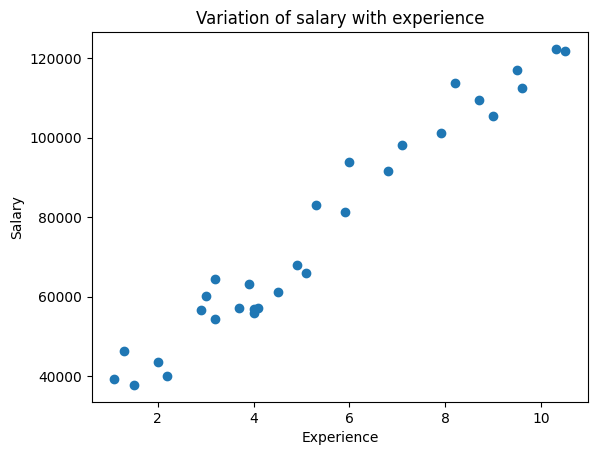

In [ ]:
plt.scatter(X,Y)
plt.xlabel("Experience")
plt.ylabel("Salary")
plt.title("Variation of salary with experience")
plt.show()


In [ ]:
#normalising the dataset
def mean(X):
  return np.sum(X)/len(X)

In [ ]:
def variance(X):
  mean_val=mean(X)
  return np.sum((X-mean_val)**2)/len(X)

In [ ]:
def normalisation(X):
  mean_val=mean(X)
  variance_val=variance(X)
  return (X-mean_val)/np.sqrt(variance_val)


In [ ]:
X_norm=normalisation(X)

In [ ]:
X_norm

array([-1.51005294, -1.43837321, -1.36669348, -1.18749416, -1.11581443,
       -0.86493538, -0.82909552, -0.75741579, -0.75741579, -0.57821647,
       -0.50653674, -0.47069688, -0.47069688, -0.43485702, -0.29149756,
       -0.1481381 , -0.07645838, -0.00477865,  0.21026054,  0.2461004 ,
        0.53281931,  0.6403389 ,  0.92705781,  1.03457741,  1.21377673,
        1.32129632,  1.50049564,  1.5363355 ,  1.78721455,  1.85889428])

In [ ]:
print(np.mean(X_norm))
print(np.std(X_norm))

-7.401486830834377e-18
1.0


In [ ]:
#prediction function
def prediction_function(X,m,b):
  return m*X+b

In [ ]:
#cost function to check how wrong the model is using MSE.
def cost(X,Y,m,b):
  n=len(X)
  prediction=prediction_function(X,m,b)
  cost_fn=(np.sum(Y-prediction)**2)/n
  return cost_fn

In [ ]:
#checking initial errors to check how bad the model initially is.
m=0
b=0
print(cost(X_norm,Y,m,b))

173293680270.0


In [ ]:
#okay, the error is actually bad, let us refine our model using gradient dissent method.
#adjusts slope and intercept step by step to reduce the cost.
def gradient_dissent(X,Y,m,b,learning_rate,epochs):
  n=len(X) #no. of data points
  for i in range(epochs):
    prediction=prediction_function(X,m,b)

    #calc gradients (how much m and b should change)
    dm = (-2/n) * np.sum(X * (Y - prediction))
    db = (-2/n) * np.sum(Y - prediction)

    m = m - learning_rate * dm
    b = b - learning_rate * db

  return m, b


In [ ]:
#printing the best parametres of the model learnt from gradient dissent.
m = 0
b = 0

m, b = gradient_dissent(X_norm, Y, m, b, 0.01, 1000)

print("Slope (m):", m)
print("Intercept (b):", b)

Slope (m): 26367.182399167323
Intercept (b): 76002.99987208944


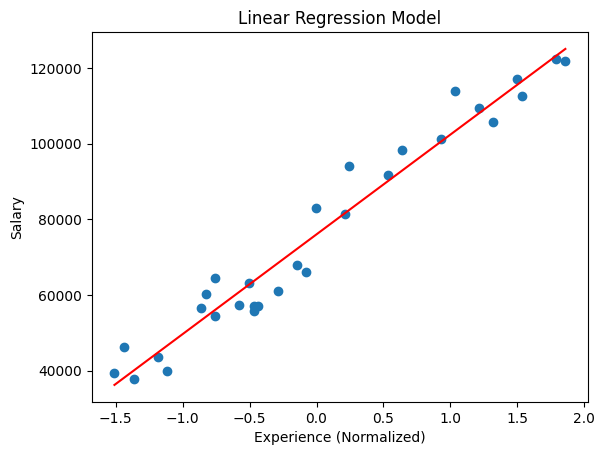

In [ ]:
predictions = prediction_function(X_norm, m, b)

plt.scatter(X_norm, Y)
plt.plot(X_norm, predictions, color="red")

plt.xlabel("Experience (Normalized)")
plt.ylabel("Salary")
plt.title("Linear Regression Model")

plt.show()

In [ ]:
def predict_salary(experience, X, m, b):

    experience_norm = (experience - np.mean(X)) / np.std(X)
    salary = prediction_function(experience_norm, m, b)

    return salary

In [ ]:
print("Salary for 5 years experience:", predict_salary(5, X, m, b))

print("Salary for 7 years experience:", predict_salary(7, X, m, b))

print("Salary for 10 years experience:", predict_salary(10, X, m, b))

Salary for 5 years experience: 73042.01168301675
Salary for 7 years experience: 91941.93629411896
Salary for 10 years experience: 120291.82321077224
